# Pipeline Creation using MotherSettings

In this example, we demonstrate how to use the MotherSettings file to generate a pipeline using defaults. To simplify this step an example config file is provided by the mother package. However, own files can be loaded in the same way.
First, all steps are performed individually to exemplify what happens in each step. Second, it is shown how a complete training pipeline with defaults is created in 5 lines of code.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn import pipeline as sklearn_pipeline
import typing

from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import PandasTools

import mother.ml as ml
from mother import feature_generation as fg

from mother.settings import MotherSettings
from mother import pipeline_utils as mother_takes_care
import logging

PandasTools.RenderImagesInAllDataFrames(True)
logging.basicConfig(level=logging.INFO)
project_dir: Path = Path.cwd().parent  # Points to examples/notebooks/ directory
project_dir

PosixPath('/workspaces/mother-ml/examples/notebooks')

### Load default settings file from mother package

In [2]:
mother_settings: MotherSettings = MotherSettings.create()
mother_settings.model.categorical_features = []  # remove categorical features
mother_settings

{
    "input": {
        "file": "examples/notebooks/freesolv_train.csv",
        "separator": ",",
        "structure_col": "smiles",
        "target_columns": [
            "expt"
        ],
        "group_col": "cat_col"
    },
    "pipeline": {
        "memory": null,
        "verbose": false,
        "transform": "pandas",
        "n_jobs": null,
        "remainder": "passthrough",
        "verbose_feature_names_out": false
    },
    "preprocessing": {
        "flags": [
            "STANDARDIZE",
            "NEUTRALIZE",
            "DESALT"
        ]
    },
    "feature_generation": {
        "fingerprints": [
            {
                "MorganFP": {
                    "radius": 2,
                    "fpSize": 1024,
                    "includeChirality": false
                }
            }
        ],
        "maccs": true,
        "chemical_descriptors": {
            "omit_prefixes": [
                "fr_",
                "FpDensity"
            ],
            "desc

If you want to dump the config you can use the following function. Afterwards you can edit the file and reload it again

In [3]:
mother_settings.dump_to_yaml(project_dir.joinpath("my_mother_settings.yaml"))

### Load input data from input file

In [4]:
input_file: Path = Path("../freesolv_train.csv")
data: pd.DataFrame = pd.read_csv(input_file, sep=",")
data = data.loc[:100, ["iupac", "smiles", "expt"]]
data.head()

,iupac,smiles,expt
0,"4-methoxy-N,N-dimethyl-benzamide",CN(C)C(=O)c1ccc(cc1)OC,-11.01
1,methanesulfonyl chloride,CS(=O)(=O)Cl,-4.87
2,3-methylbut-1-ene,CC(C)C=C,1.83
3,2-ethylpyrazine,CCc1cnccn1,-5.45
4,heptan-1-ol,CCCCCCCO,-4.21


The compound preprocessing has to be performed in advance to create the required groups for the CV and FeatureSelector

In [5]:
# preprocessing
preprocessor: sklearn_pipeline.Pipeline = mother_takes_care.get_preprocessing_pipeline(settings=mother_settings)
preprocessor.set_output(transform=mother_settings.pipeline.transform)

Pipeline(steps=[('smiles_standardizer',
                 StandardizerTransformer(flags=['STANDARDIZE', 'NEUTRALIZE',
                                                'DESALT'])),
                ('smiles_to_mol', SmilesToMolTransformer())])

In [6]:
structure_data: pd.Series = data[mother_settings.input.structure_col]
mol_data: pd.DataFrame = preprocessor.fit_transform(structure_data)  # type: ignore
preprocessor

INFO:mother.preprocessing.core:Standardizing SMILES with flags: ['STANDARDIZE', 'NEUTRALIZE', 'DESALT']
[08:09:33] Initializing Normalizer
[08:09:33] Initializing Normalizer
[08:09:33] Initializing Normalizer
[08:09:33] Initializing MetalDisconnector
[08:09:33] Initializing Normalizer
[08:09:33] Initializing Normalizer
[08:09:33] Initializing MetalDisconnector
[08:09:33] Initializing Normalizer


Pipeline(steps=[('smiles_standardizer',
                 StandardizerTransformer(flags=['STANDARDIZE', 'NEUTRALIZE',
                                                'DESALT'])),
                ('smiles_to_mol', SmilesToMolTransformer())])

In [7]:
mol_data.columns

Index(['Molecule'], dtype='object')

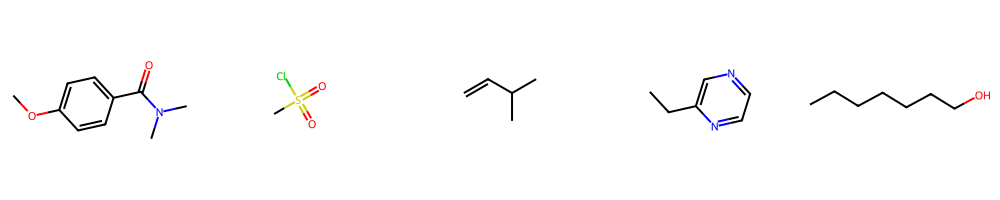

In [8]:
molecule_col: str = "Molecule"
Draw.MolsToGridImage(mol_data[molecule_col].head(), molsPerRow=5, subImgSize=(200, 200))

## Get CV data and folds

In the following the groups are gemerated using the mother convenience functions. This function creates the required transformer and returns the groups as a result

INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'
INFO:mother.cv.cv_methods:Applying clustering with Tanimoto similarity: 0.4
INFO:mother.cv.cv_methods:Applying clustering with Tanimoto similarity: 0.4
INFO:mother.cv.cv_methods:Found: 42 clusters
INFO:mother.cv.cv_methods:Found: 42 clusters


array([[<Axes: title={'center': 'tanimoto-group'}>]], dtype=object)

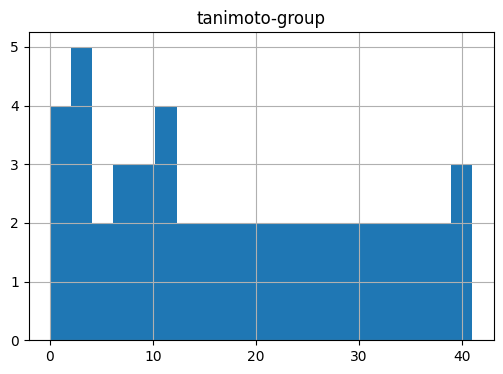

In [9]:
groups: typing.Optional[pd.DataFrame] = mother_takes_care.get_groups(
    settings=mother_settings, mol_data=mol_data[molecule_col]
)
assert groups is not None
groups.hist(xlabelsize=10, ylabelsize=10, bins=20, figsize=(6, 4))

In [10]:
from mother.cv import report as cv_report

Now generate the CV folds for the training/validation. Here, since we are training a regression model, you get a GroupKFold cross-validator.
If you want to train a classification model, you automatically get a StratifiedGroupKFold cross-validator.

In [11]:
import sklearn.model_selection as skl_model_sel

cv: skl_model_sel.BaseCrossValidator = mother_takes_care.get_cv_folds(settings=mother_settings, group_data=groups)
cv

INFO:mother.pipeline_utils:Creating GroupKFold cross-validator using 5 splits


GroupKFold(n_splits=5)

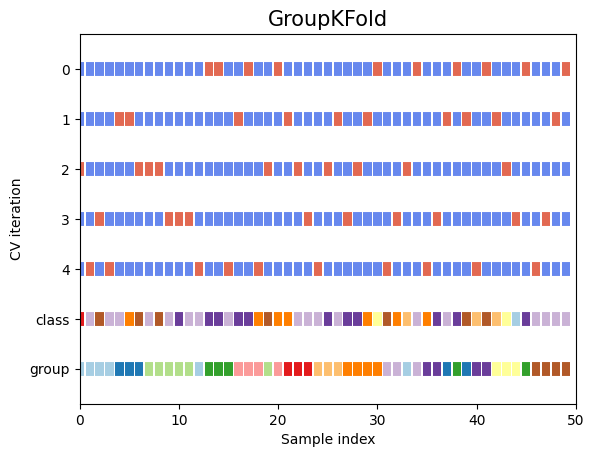

In [12]:
from matplotlib import pyplot as plt

cv_report.plot_cv_indices(
    cv=cv,
    X=np.array(mol_data),
    y=data["expt"],
    group=groups.iloc[:, 0].values,  # Extract the first (and likely only) column of group data as array
    ax=plt.gca(),
    n_splits=mother_settings.cv.n_splits,
)

### Next step would be the feature generation.

In [13]:
from sklearn.pipeline import FeatureUnion

feature_data: Path = project_dir.joinpath(Path(mother_settings.input.file).stem + "_features.csv")

feature_generator: FeatureUnion = mother_takes_care.get_feature_generation_pipeline(settings=mother_settings)
feature_generator.set_output(transform=mother_settings.pipeline.transform)
feature_matrix: pd.DataFrame = feature_generator.fit_transform(mol_data[molecule_col])
# ensure valid dtypes for feature selection
feature_matrix = feature_matrix.convert_dtypes()
feature_matrix.shape

INFO:mother.pipeline_utils:Creating feature generation pipeline
INFO:mother.pipeline_utils:Feature generation pipeline created
INFO:mother.feature_generation.core:Calculating MACCS fingerprints
INFO:mother.pipeline_utils:Feature generation pipeline created
INFO:mother.feature_generation.core:Calculating MACCS fingerprints
INFO:mother.feature_generation.core:Calculating MorganFP fingerprints using parameters: {'fpSize': 1024, 'countSimulation': False, 'countBounds': None, 'atomInvariantsGenerator': None, 'radius': 2, 'includeChirality': False, 'useBondTypes': True, 'includeRedundantEnvironments': False, 'includeRingMembership': True, 'onlyNonzeroInvariants': False}
INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'
INFO:mother.feature_generation.core:Calculating MorganFP fingerprints using parameters: {'fpSize': 1024, 'countSimulation': False, 'countBounds': None, 'atomInvariantsGenerator': None, 'radius': 2, 'includeChirality': False, 'useBondTypes': True, 

(50, 1320)

Visualize Feature Union

In [14]:
feature_matrix.head()

,Maccs__maccs_0,Maccs__maccs_1,Maccs__maccs_2,Maccs__maccs_3,Maccs__maccs_4,Maccs__maccs_5,Maccs__maccs_6,Maccs__maccs_7,Maccs__maccs_8,Maccs__maccs_9,...,MorganFP__MorganFP_1014,MorganFP__MorganFP_1015,MorganFP__MorganFP_1016,MorganFP__MorganFP_1017,MorganFP__MorganFP_1018,MorganFP__MorganFP_1019,MorganFP__MorganFP_1020,MorganFP__MorganFP_1021,MorganFP__MorganFP_1022,MorganFP__MorganFP_1023
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
feature_generator

FeatureUnionWithHyperparameterRooting(transformer_list=[('Maccs',
                                                         MaccsFingerprints()),
                                                        ('Desc',
                                                         ChemicalDescriptors(descriptor_list=['MaxAbsEStateIndex',
                                                                                              'MaxEStateIndex',
                                                                                              'MinAbsEStateIndex',
                                                                                              'MinEStateIndex',
                                                                                              'qed',
                                                                                              'SPS',
                                                                                              'MolWt',
                                                                                              'HeavyAtomMolWt',
                                                                                              'ExactMolWt',
                                                                                              'NumValenceElectrons',
                                                                                              'NumRadicalElectrons',
                                                                                              'MaxPartialCharge',
                                                                                              'MinPartialCharge',
                                                                                              'MaxAbsPartia...
                                                                             descriptor_prefix='rdkit_',
                                                                             omit_prefixes=('fr_',
                                                                                            'FpDensity'))),
                                                        ('MorganFP',
                                                         FingerprintsGeneric(fp_type='MorganFP',
                                                                             parameters={'atomInvariantsGenerator': None,
                                                                                         'countBounds': None,
                                                                                         'countSimulation': False,
                                                                                         'fpSize': 1024,
                                                                                         'includeChirality': False,
                                                                                         'includeRedundantEnvironments': False,
                                                                                         'includeRingMembership': True,
                                                                                         'onlyNonzeroInvariants': False,
                                                                                         'radius': 2,
                                                                                         'useBondTypes': True}))])

### Feature Selection

Use default feature selection provided by mother. Catboost model used in feature selector is silenced via mother settings. just as an example, the default loss function is replaced.

In [16]:
mother_settings.model.parameters["loss_function"] = "Quantile"
mother_settings.model.parameters["silent"] = True
mother_settings.model.feature_selection_type = "catboost"
mother_settings.model.correlation_threshold = 0.95  # drop highly correlated features
mother_settings.model.feature_selection_threshold = 0.1  # drop unimportant features
mother_settings.model.feature_selection_flags = [
    "DROP_CONSTANT",
    "DROP_CORRELATED",
    "DROP_DUPLICATES",
    "DROP_UNIMPORTANT",
]
feature_selector = mother_takes_care.get_feature_selection_pipeline(
    settings=mother_settings,
    cv=None,  # use internal CV since CV with groups is not supported
)
feature_selector.set_output(transform=mother_settings.pipeline.transform)
feature_matrix_sel: pd.DataFrame = feature_selector.fit_transform(
    feature_matrix, data[mother_settings.input.target_columns]
)
feature_matrix_sel.shape

INFO:mother.pipeline_utils:Creating feature selection pipeline for numeric columns.
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.ml:Loaded 9 model classes: RandomForestClassifierMother, RandomForestRegressorMother, CatboostClassifierMother, CatboostGaussianProcessRegressorMother, CatboostRankerMother, CatboostRegressorMother, LassoClassifierBinaryMother, LassoClassifierMulticlassMother, LassoRegressorMother
INFO:mother.ml.utils:Using 'RMSE' as loss function.
INFO:mother.pipeline_utils:Setting up catboost importance feature selection
INFO:mother.ml:Loaded 9 model classes: RandomForestClassifierMother, RandomForestRegressorMother, CatboostClassifierMother, CatboostGaussianProcessRegressorMother, CatboostRankerMother, CatboostRegressorMother, LassoClassifierBinaryMother, LassoClassifierMulticlassMot

(50, 208)

#### Visualization of the Feature Selector

Since there is no categorical column in the input, the CategoricalImputer is not used. The used feature selectors are part of a pipeline that runs consecutively on all input columns.

In [17]:
mother_takes_care.report_feature_selection(feature_selector, data=feature_matrix)

INFO:mother.pipeline_utils:Analyzing feature selection pipeline
INFO:mother.pipeline_utils:Analyzing feature_selector transformer
INFO:mother.pipeline_utils:Nested pipeline found
INFO:mother.pipeline_utils:Pipeline step: duplicate_selector
INFO:mother.pipeline_utils:Features to drop: {'MorganFP__MorganFP_215', 'MorganFP__MorganFP_399', 'MorganFP__MorganFP_885', 'Maccs__maccs_17', 'MorganFP__MorganFP_681', 'MorganFP__MorganFP_271', 'MorganFP__MorganFP_50', 'MorganFP__MorganFP_225', 'MorganFP__MorganFP_193', 'Desc__rdkit_NumAromaticHeterocycles', 'MorganFP__MorganFP_995', 'MorganFP__MorganFP_699', 'MorganFP__MorganFP_972', 'MorganFP__MorganFP_223', 'MorganFP__MorganFP_713', 'Maccs__maccs_106', 'MorganFP__MorganFP_897', 'MorganFP__MorganFP_408', 'MorganFP__MorganFP_530', 'MorganFP__MorganFP_929', 'MorganFP__MorganFP_113', 'MorganFP__MorganFP_482', 'MorganFP__MorganFP_198', 'MorganFP__MorganFP_212', 'MorganFP__MorganFP_456', 'MorganFP__MorganFP_672', 'MorganFP__MorganFP_292', 'MorganFP__Mo

In [18]:
feature_selector

ColumnTransformerWithHyperparameterRooting(remainder='passthrough',
                                           transformers=[('feature_selector',
                                                          PipelineWithHyperparameterRooting(steps=[('duplicate_selector',
                                                                                                    DropDuplicateFeatures()),
                                                                                                   ('constant_selector',
                                                                                                    DropConstantFeatures(missing_values='ignore')),
                                                                                                   ('correlation_selector',
                                                                                                    SmartCorrelatedSelection(selection_method='variance',
                                                                                                                             threshold=0.95)),
                                                                                                   ('importance_selector',
                                                                                                    MotherSelectFromModel(estimator=MotherCatboostImportance(estimator=<catboost.core.CatBoostRegressor object at 0x72d415a176d0>,
                                                                                                                                                             max_depth=6),
                                                                                                                          threshold=0.1))]),
                                                          <function get_numeric_columns at 0x72d3b72711c0>)],
                                           verbose_feature_names_out=False)

# Creating a training pipeline from a settings object

Here you can see how a complete training pipeline can be generated using the convenience functions from mother and the required settings.

The steps to be performed are:

1. Preprocess the input data
    1. Standardize SMILES
    2. Convert SMILES to rdkit molecule
2. Create input features from the molecules
    1. Calculate morgan fingerprint
    2. Calculate MACSS keys
    3. Calculate rdkit physchem descriptors
3. Run feature selector
4. Train the model

In [19]:
from sklearn.pipeline import FeatureUnion, Pipeline

# silence catboost learning output
mother_settings.model.parameters["silent"] = True
model_steps: typing.Sequence[
    typing.Tuple[str, typing.Union[Pipeline, FeatureUnion, ml.AbstractMotherPipeline, typing.Any]]
] = []
model_steps.append(
    (
        "preprocessor",
        mother_takes_care.get_preprocessing_pipeline(settings=mother_settings),
    )
)
model_steps.append(
    (
        "feature_generator",
        mother_takes_care.get_feature_generation_pipeline(settings=mother_settings),
    )
)
model_steps.append(
    (
        "feature_selector",
        mother_takes_care.get_feature_selection_pipeline(settings=mother_settings),
    )
)
model_steps.append(("model", mother_takes_care.get_model(settings=mother_settings)))
training_pipeline: Pipeline = Pipeline(
    steps=model_steps,
    memory=mother_settings.pipeline.memory,
    verbose=mother_settings.pipeline.verbose,
)
training_pipeline.set_output(transform=mother_settings.pipeline.transform)

INFO:mother.pipeline_utils:Creating feature generation pipeline
INFO:mother.pipeline_utils:Feature generation pipeline created
INFO:mother.pipeline_utils:Feature generation pipeline created
INFO:mother.pipeline_utils:Creating feature selection pipeline for numeric columns.
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.ml.utils:Using 'RMSE' as loss function.
INFO:mother.pipeline_utils:Setting up catboost importance feature selection
INFO:mother.pipeline_utils:Creating feature selection pipeline for numeric columns.
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.ml.utils:Using 'RMSE' as loss function.
INFO:mother.pipeline_utils:Setting up catboost importance feature selection


Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('smiles_standardizer',
                                  StandardizerTransformer(flags=['STANDARDIZE',
                                                                 'NEUTRALIZE',
                                                                 'DESALT'])),
                                 ('smiles_to_mol', SmilesToMolTransformer())])),
                ('feature_generator',
                 FeatureUnionWithHyperparameterRooting(transformer_list=[('Maccs',
                                                                          MaccsFingerprints()),
                                                                         ('Desc',
                                                                          ChemicalDescriptors(descriptor_prefix='rdkit_',
                                                                                              o...
                                                                                                                                              threshold=0.95)),
                                                                                                                    ('importance_selector',
                                                                                                                     MotherSelectFromModel(estimator=MotherCatboostImportance(estimator=<catboost.core.CatBoostRegressor object at 0x72d3aa3deb50>,
                                                                                                                                                                              max_depth=6),
                                                                                                                                           threshold=0.1))]),
                                                                           <function get_numeric_columns at 0x72d3b72711c0>)],
                                                            verbose_feature_names_out=False)),
                ('model',
                 <mother.ml.models.m_catboost.CatboostRegressorMother object at 0x72d3aa5baa90>)])

In the following the model is fit on the training data. The final pipeline is again visualized. You should see a blue coloring of the invidual transformers that indicates that the individual steps are fitted and ready to be used for inference.

In [20]:
training_pipeline.fit(
    data[mother_settings.input.structure_col],
    data[mother_settings.input.target_columns],
)

INFO:mother.preprocessing.core:Standardizing SMILES with flags: ['STANDARDIZE', 'NEUTRALIZE', 'DESALT']
[08:09:46] Initializing Normalizer
[08:09:46] Initializing Normalizer
[08:09:46] Initializing MetalDisconnector
[08:09:46] Initializing Normalizer
[08:09:46] Initializing Normalizer
[08:09:46] Initializing MetalDisconnector
[08:09:46] Initializing Normalizer
[08:09:46] Initializing Normalizer
INFO:mother.feature_generation.core:Calculating MACCS fingerprints
INFO:mother.feature_generation.core:Calculating MACCS fingerprints
INFO:mother.feature_generation.core:Calculating MorganFP fingerprints using parameters: {'fpSize': 1024, 'countSimulation': False, 'countBounds': None, 'atomInvariantsGenerator': None, 'radius': 2, 'includeChirality': False, 'useBondTypes': True, 'includeRedundantEnvironments': False, 'includeRingMembership': True, 'onlyNonzeroInvariants': False}
INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'
INFO:mother.feature_generation.core:Cal

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('smiles_standardizer',
                                  StandardizerTransformer(flags=['STANDARDIZE',
                                                                 'NEUTRALIZE',
                                                                 'DESALT'])),
                                 ('smiles_to_mol', SmilesToMolTransformer())])),
                ('feature_generator',
                 FeatureUnionWithHyperparameterRooting(transformer_list=[('Maccs',
                                                                          MaccsFingerprints()),
                                                                         ('Desc',
                                                                          ChemicalDescriptors(descriptor_list=['MaxAbsESta...
                                                                                                                                              threshold=0.95)),
                                                                                                                    ('importance_selector',
                                                                                                                     MotherSelectFromModel(estimator=MotherCatboostImportance(estimator=<catboost.core.CatBoostRegressor object at 0x72d3aa3deb50>,
                                                                                                                                                                              max_depth=6),
                                                                                                                                           threshold=0.1))]),
                                                                           <function get_numeric_columns at 0x72d3b72711c0>)],
                                                            verbose_feature_names_out=False)),
                ('model',
                 <mother.ml.models.m_catboost.CatboostRegressorMother object at 0x72d3aa5baa90>)])

## Inference

Create predictions on SMILES. Since the first step of the pipeline takes SMILES as input, those are used for inference as well. If the preprocessing and feature generation steps would be removed, the input would be a feature matrix with all required columns. The result of the predict function is a numpy array. Since all necessary preprocessing steps are part of the pipeline. The pipeline can be pickled and used on a different machine (having the same python environment and dependencies installed) to do inference.

In [21]:
import pickle

pickle.dump(training_pipeline, open("/tmp/pipeline.pkl.gz", "wb"))

In [22]:
training_pipeline: Pipeline = pickle.load(open("/tmp/pipeline.pkl.gz", "rb"))
predictions = training_pipeline.predict(data[mother_settings.input.structure_col])
predictions

INFO:mother.preprocessing.core:Standardizing SMILES with flags: ['STANDARDIZE', 'NEUTRALIZE', 'DESALT']
[08:09:54] Initializing Normalizer
[08:09:54] Initializing Normalizer
[08:09:54] Initializing MetalDisconnector
[08:09:54] Initializing Normalizer
[08:09:54] Initializing Normalizer
[08:09:54] Initializing MetalDisconnector
[08:09:54] Initializing Normalizer
[08:09:54] Initializing Normalizer
INFO:mother.feature_generation.core:Calculating MACCS fingerprints
INFO:mother.feature_generation.core:Calculating MACCS fingerprints
INFO:mother.feature_generation.core:Calculating MorganFP fingerprints using parameters: {'fpSize': 1024, 'countSimulation': False, 'countBounds': None, 'atomInvariantsGenerator': None, 'radius': 2, 'includeChirality': False, 'useBondTypes': True, 'includeRedundantEnvironments': False, 'includeRingMembership': True, 'onlyNonzeroInvariants': False}
INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'
INFO:mother.feature_generation.core:Cal

array([-11.01000003,  -4.87000056,   1.82999995,  -5.44999895,
        -4.20999991,  -6.2700008 ,   2.33968689,  -3.92000095,
         1.57999987,  -4.62000065,  -1.96000066,  -3.88000023,
        -4.33000085,  -2.49000066,  -2.54999904,  -4.78000009,
        -1.46000086,  -2.22212807,  -5.8499856 ,   2.87999969,
        -6.34000013,  -6.0999947 ,  -5.48000059,  -4.09999964,
        -4.10000074,  -3.51999926,  -4.4699993 ,  -2.74000093,
        -3.43000021,  -7.81000427,  -0.80000058,   0.93      ,
        -6.78000103,  -9.29000052,  -4.07000065,  -5.91000111,
        -2.12999969,  -3.64000036,  -2.68000045,   3.12898262,
       -10.00000031,   2.06000509,  -8.10999683,  -1.12044034,
       -23.62000182,  -2.86802731,  -4.67999982,  -5.56000065,
        -3.65000048,  -5.48999989])

## Example how to access individual parts of the pipeline

You can access each pipeline step by using the name given when the training pipeline was created.

Here, using *model* returns us the catboost object and catboost functions can be used. Here, the feature importance from the model is extracted and visualized.

In [23]:
mother_takes_care.get_feature_importance(pipeline=training_pipeline, model_step_name="model", lowest_importance=1)

,Feature Id,Importances
0,Desc__rdkit_PEOE_VSA1,"8,411"
1,Desc__rdkit_SMR_VSA1,"6,155"
2,Desc__rdkit_NOCount,"4,278"
3,Desc__rdkit_NumHAcceptors,"3,992"
4,Desc__rdkit_VSA_EState8,"3,794"
5,Desc__rdkit_BCUT2D_MRHI,"3,585"
6,Desc__rdkit_TPSA,"3,583"
7,Desc__rdkit_SMR_VSA6,"2,694"
8,Desc__rdkit_NHOHCount,"2,674"
9,Desc__rdkit_MolLogP,"2,660"


## Model Tuning using Custom Preprocessing
In the following section the Tuner is used for preprocessing as well.

First, create TunableTransformer for feature generations steps. To be sure that all required methods are implemented, please inherit from 'AbstractMotherPipeline'.

In [24]:
from mother.ml.core import AbstractMotherPipeline
from optuna.trial import Trial

In [25]:
class TunableFeatureGenerationPipeline(fg.MorganFingerprints, AbstractMotherPipeline):
    def transform(self, X, **kwargs):
        return super().transform(X, **kwargs)

    def get_hyperparameter_space(self, X, y, trial: Trial, prefix: str = "") -> dict:
        return {
            prefix + "radius": trial.suggest_int(prefix + "radius", low=1, high=3, step=1),
            prefix + "fpSize": trial.suggest_int(
                prefix + "fpSize",
                low=512,
                step=256,
                high=2048,
            ),
        }

    def default_parameters(self, prefix=""):
        return {
            prefix + "radius": 2,
            prefix + "fpSize": 666,
        }

In [26]:
import mother.optimization as opt

assert mother_settings.tuning is not None

model_steps: typing.List[typing.Union[Pipeline, FeatureUnion, ml.AbstractMotherPipeline, typing.Any]] = []

model_steps.append(
    (
        "preprocessor",
        mother_takes_care.get_preprocessing_pipeline(settings=mother_settings),
    )
)
model_steps.append(("feature_generator", TunableFeatureGenerationPipeline()))  # custom feature generation for tuning
model_steps.append(
    (
        "feature_selector",
        mother_takes_care.get_feature_selection_pipeline(settings=mother_settings),
    )
)
model_steps.append(("model", mother_takes_care.get_model(settings=mother_settings)))
tuning_pipeline: ml.PipelineWithHyperparameterRooting = ml.PipelineWithHyperparameterRooting(steps=model_steps)
tuning_pipeline.set_output(transform="pandas")
tuning_pipeline

INFO:mother.pipeline_utils:Creating feature selection pipeline for numeric columns.
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.ml.utils:Using 'RMSE' as loss function.
INFO:mother.pipeline_utils:Setting up catboost importance feature selection
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.ml.utils:Using 'RMSE' as loss function.
INFO:mother.pipeline_utils:Setting up catboost importance feature selection


PipelineWithHyperparameterRooting(steps=[('preprocessor',
                                          Pipeline(steps=[('smiles_standardizer',
                                                           StandardizerTransformer(flags=['STANDARDIZE',
                                                                                          'NEUTRALIZE',
                                                                                          'DESALT'])),
                                                          ('smiles_to_mol',
                                                           SmilesToMolTransformer())])),
                                         ('feature_generator',
                                          TunableFeatureGenerationPipeline()),
                                         ('feature_selector',
                                          ColumnTransformerWithHyperparameterRooting(remainder='passthr...
                                                                                                                                                                       threshold=0.95)),
                                                                                                                                             ('importance_selector',
                                                                                                                                              MotherSelectFromModel(estimator=MotherCatboostImportance(estimator=<catboost.core.CatBoostRegressor object at 0x72d415c41a90>,
                                                                                                                                                                                                       max_depth=6),
                                                                                                                                                                    threshold=0.1))]),
                                                                                                    <function get_numeric_columns at 0x72d3b72711c0>)],
                                                                                     verbose_feature_names_out=False)),
                                         ('model',
                                          <mother.ml.models.m_catboost.CatboostRegressorMother object at 0x72d3aa54f450>)])

In [27]:
data.head()

,iupac,smiles,expt
0,"4-methoxy-N,N-dimethyl-benzamide",CN(C)C(=O)c1ccc(cc1)OC,-11.01
1,methanesulfonyl chloride,CS(=O)(=O)Cl,-4.87
2,3-methylbut-1-ene,CC(C)C=C,1.83
3,2-ethylpyrazine,CCc1cnccn1,-5.45
4,heptan-1-ol,CCCCCCCO,-4.21


In [28]:
import sklearn.metrics as skl_metrics

scorer = skl_metrics.make_scorer(score_func=skl_metrics.root_mean_squared_error, greater_is_better=False)

In [29]:
tuning_pipeline

PipelineWithHyperparameterRooting(steps=[('preprocessor',
                                          Pipeline(steps=[('smiles_standardizer',
                                                           StandardizerTransformer(flags=['STANDARDIZE',
                                                                                          'NEUTRALIZE',
                                                                                          'DESALT'])),
                                                          ('smiles_to_mol',
                                                           SmilesToMolTransformer())])),
                                         ('feature_generator',
                                          TunableFeatureGenerationPipeline()),
                                         ('feature_selector',
                                          ColumnTransformerWithHyperparameterRooting(remainder='passthr...
                                                                                                                                                                       threshold=0.95)),
                                                                                                                                             ('importance_selector',
                                                                                                                                              MotherSelectFromModel(estimator=MotherCatboostImportance(estimator=<catboost.core.CatBoostRegressor object at 0x72d415c41a90>,
                                                                                                                                                                                                       max_depth=6),
                                                                                                                                                                    threshold=0.1))]),
                                                                                                    <function get_numeric_columns at 0x72d3b72711c0>)],
                                                                                     verbose_feature_names_out=False)),
                                         ('model',
                                          <mother.ml.models.m_catboost.CatboostRegressorMother object at 0x72d3aa54f450>)])

To see why you need a PipelineWithHyperparameterRooting class and what it is doing for you, have a look at the default_parameters of your pipeline.

In [30]:
tuning_pipeline.default_parameters()

{'feature_generator__radius': 2,
 'feature_generator__fpSize': 666,
 'feature_selector__feature_selector__importance_selector__threshold': np.float64(2.2250738585072014e-308),
 'model__learning_rate': 0.03,
 'model__bootstrap_type': 'Bayesian',
 'model__random_strength': 1,
 'model__grow_policy': 'SymmetricTree',
 'model__boosting_type': 'Plain',
 'model__max_depth': 6,
 'model__loss_function': 'RMSE'}

In [31]:
tuner = opt.MotherTuner(**mother_settings.tuning.model_dump())
tuner.scorer = scorer
tuner = opt.MotherTuner(
    n_threads_optuna=5,
    scorer=scorer,
    n_trials_optuna=1,
    n_startup_trials=1,
    tuning_direction="maximize",
)
# tune the pipeline
model_tuned = tuner.optimize(
    estimator=tuning_pipeline,
    X=data[[mother_settings.input.structure_col]],
    y=data[mother_settings.input.target_columns],
    cross_validation=cv,
    groups=groups.iloc[:, 0],
)

model_tuned

/workspaces/mother-ml/.venv/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  warnings.warn(
INFO:mother.optimization.core:Setting up Optuna to optimize hyperparameters with direction: maximize
INFO:optuna.storages._in_memory:A new study created in memory with name: no-name-cb0589d7-7daa-47cd-8c15-203ff6170746
INFO:mother.optimization.core:Running hyperparameter optimization with 1 trials
/workspaces/mother-ml/.venv/lib/python3.11/site-packages

{'feature_generator__radius': 2, 'feature_generator__fpSize': 666, 'feature_selector__feature_selector__importance_selector__threshold': 2.2250738585072014e-308, 'model__bootstrap_type': 'Bayesian', 'model__learning_rate': 0.03, 'model__random_strength': 1.0, 'model__grow_policy': 'SymmetricTree', 'model__boosting_type': 'Plain', 'model__max_depth': 6}


INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator
INFO:mother.optimization.core:Training completed
INFO:mother.optimization.core:Training completed


PipelineWithHyperparameterRooting(steps=[('preprocessor',
                                          Pipeline(steps=[('smiles_standardizer',
                                                           StandardizerTransformer(flags=['STANDARDIZE',
                                                                                          'NEUTRALIZE',
                                                                                          'DESALT'])),
                                                          ('smiles_to_mol',
                                                           SmilesToMolTransformer())])),
                                         ('feature_generator',
                                          TunableFeatureGenerationPipeline(fpSize=666)),
                                         ('feature_selector',
                                          ColumnTransformerWithHyperparameterRooting(remainde...
                                                                                                                                             ('importance_selector',
                                                                                                                                              MotherSelectFromModel(estimator=MotherCatboostImportance(estimator=<catboost.core.CatBoostRegressor object at 0x72d3aa0c2050>,
                                                                                                                                                                                                       max_depth=6),
                                                                                                                                                                    threshold=2.2250738585072014e-308))]),
                                                                                                    <function get_numeric_columns at 0x72d3b72711c0>)],
                                                                                     verbose_feature_names_out=False)),
                                         ('model',
                                          <mother.ml.models.m_catboost.CatboostRegressorMother object at 0x72d3b517b590>)])